In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import itertools
import seaborn as sns
from functools import reduce
%matplotlib inline

# Visualization Function

In [2]:
def category_plotting_detailed(x, y, data, order):
    fig,ax = plt.subplots()
    sns.set(rc={'figure.figsize':(3,5)})
    sns.set(font="Roboto")
    sns.set(font_scale=2)
    sns.set_style("white")

    sns.boxplot(x = x,
                y = y,
                data = data,
                palette = ['gainsboro', 'red'],
                order = order)

    sns.swarmplot(x = x,
                  y = y,
                  data = data,
                  dodge = True, color = 'black',
                  order = order)   
    sns.despine() 

    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .7))
        
    return ax 


# Data Import

import general behaviour scoring dataset

In [3]:
raw_df = pd.read_csv('negative_parental_switch_summary.csv',encoding='cp1252')

agg_cond_data_first = raw_df[(raw_df['exp_cond'].isin(['food_deprivation', 'all_stressor_5h'])) & 
                            (raw_df['exp_time'] == 1)]

import detailed behaviour analysis dataset

In [4]:
df = pd.read_csv('observations.tsv',sep='\t')
df = pd.concat([df['Observation id'].str.split(',', expand=True), df], axis=1)
df = df.rename(columns={0: 'id_1', 1: 'id_2', 2: 'phase'})
df.head()

,id_1,id_2,phase,Observation id,Observation date,Description,Media file,Total length,FPS,pre,...,Subject,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop
0,BRAC4939.7c(R),BRAC4939.7e(L),test,"BRAC4939.7c(R),BRAC4939.7e(L),test",2021-03-14 13:27:47,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,935.244,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,8.452,8.452,NaN,NaN,NaN
1,BRAC4943.6b(R),BRAC5007.4d(L),test,"BRAC4943.6b(R),BRAC5007.4d(L),test",2021-03-14 13:28:54,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,1128.630,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,9.196,9.196,NaN,NaN,NaN
2,BRAC4895.5b(R),BRAC4895.5e(L),control,"BRAC4895.5b(R),BRAC4895.5e(L),control",2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,9.453,9.453,NaN,NaN,NaN
3,BRAC4895.5b(R),BRAC4895.5e(L),test,"BRAC4895.5b(R),BRAC4895.5e(L),test",2021-03-14 12:31:29,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,960.657,29.99,NaN,...,right,pup introduction,NaN,NaN,POINT,9.954,9.954,NaN,NaN,NaN
4,BRAC4895.5b(R),BRAC4895.5e(L),control,"BRAC4895.5b(R),BRAC4895.5e(L),control",2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,...,right,in empty nest,NaN,NaN,STATE,10.206,104.241,94.035,NaN,NaN


In [5]:
right = df[([df['id_1'][i][-3:] =='(R)' for i in range(len(df.id_1))]) & (df['Subject'] == 'right')].reset_index()
left = df[([df['id_2'][i][-3:] =='(L)' for i in range(len(df.id_2))]) & (df['Subject'] == 'left')].reset_index()
right['mice_ID'] = [right['id_1'][i][0:-3] for i in range(len(right.id_1))]
left['mice_ID'] = [left['id_2'][i][0:-3] for i in range(len(left.id_2))]
right = right.drop(['id_1', 'id_2', 'Observation id'], axis=1)
left = left.drop(['id_1', 'id_2', 'Observation id'], axis=1)
df_cleaned = pd.concat([right, left]).reset_index()
df_cleaned.head()

,level_0,index,phase,Observation date,Description,Media file,Total length,FPS,pre,post,...,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop,mice_ID
0,0,0,test,2021-03-14 13:27:47,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,935.244,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,8.452,8.452,NaN,NaN,NaN,BRAC4939.7c
1,1,1,test,2021-03-14 13:28:54,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,1128.630,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,9.196,9.196,NaN,NaN,NaN,BRAC4943.6b
2,2,2,control,2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,9.453,9.453,NaN,NaN,NaN,BRAC4895.5b
3,3,3,test,2021-03-14 12:31:29,NaN,/home/tochenan/pups-20210314T114301Z-001/pups/...,960.657,29.99,NaN,NaN,...,pup introduction,NaN,NaN,POINT,9.954,9.954,NaN,NaN,NaN,BRAC4895.5b
4,4,4,control,2021-03-15 21:55:14,NaN,/home/tochenan/pups-20210315T115336Z-001/pups/...,946.470,29.99,NaN,NaN,...,in empty nest,NaN,NaN,STATE,10.206,104.241,94.035,NaN,NaN,BRAC4895.5b


# Pre and Post phase data processing

In [6]:
df_test = df_cleaned[df_cleaned['phase'] == 'test']
df_control = df_cleaned[df_cleaned['phase'] == 'control']
df_test['corrected_start'] = df_test.groupby('mice_ID') \
                                            ['Start (s)'] \
                                           .transform(lambda x: (x -x.min()))

df_control['corrected_start'] = df_control.groupby('mice_ID') \
                                            ['Start (s)'] \
                                           .transform(lambda x: (x -x.min()))

df_test['contact_latency'] = df_test.groupby('mice_ID') \
                                            ['corrected_start'] \
                                            .transform(lambda x:(x.nsmallest(2).iloc[-1]))
df_control['contact_latency'] = df_control.groupby('mice_ID') \
                                            ['corrected_start'] \
                                            .transform(lambda x:(x.nsmallest(2).iloc[-1]))

df_test_duration = df_test.groupby(['mice_ID','Behavior'])['Duration (s)'].sum().reset_index()
df_control_duration = df_control.groupby(['mice_ID','Behavior'])['Duration (s)'].sum().reset_index()
df_test_freq = df_test.groupby(['mice_ID','Behavior']).size().reset_index(name = 'n')
df_control_freq = df_control.groupby(['mice_ID','Behavior']).size().reset_index(name = 'n')

df_test_p = df_test_duration.merge(df_test_freq, how = 'outer', on = ['mice_ID', 'Behavior'])
df_test_p = df_test_p.merge(df_test.filter(['mice_ID', 'contact_latency'], axis = 1).drop_duplicates(), how = 'left', on = 'mice_ID')
df_control_p = df_control_duration.merge(df_control_freq, how = 'outer', on = ['mice_ID', 'Behavior'])
df_control_p = df_control_p.merge(df_control.filter(['mice_ID', 'contact_latency'], axis = 1).drop_duplicates(), how = 'left', on = 'mice_ID')

df_test_p = df_test_p.merge(agg_cond_data_first.filter(['mice_ID', 'estrous_stage', 'state_after']), how = 'left', on = 'mice_ID')
df_control_p = df_control_p.merge(agg_cond_data_first.filter(['mice_ID', 'estrous_stage', 'state_after', 'retrieval_before_latency']), how = 'left', on = 'mice_ID')

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

# Thresholding Parening and Ignoring mice

In [7]:
behaviors = ['chemoinvestigation', 'licking and grooming', 
            'retrieval', 'nest building', 'in nest',
            'in empty nest', 'tail rattling', 'rearing',
            'digging', 'self-grooming']

parental_beh = ['retrieval', 'nest building', 
                'in nest']

In [8]:
parental_duration = df_control_duration.loc[df_control_duration.Behavior.isin(parental_beh)]
parental_duration = parental_duration.groupby(['mice_ID'])['Duration (s)'].sum().reset_index(name = 'parental_time')

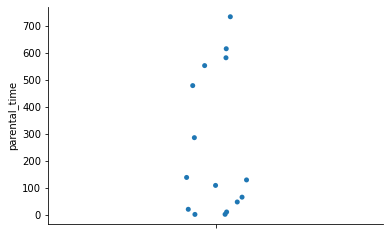

In [9]:
ax = sns.stripplot(y=parental_duration['parental_time'])
sns.despine()

# Estrous cycle effect on different parental behaviour parameters

difference in behaviour duration and estrous cycle

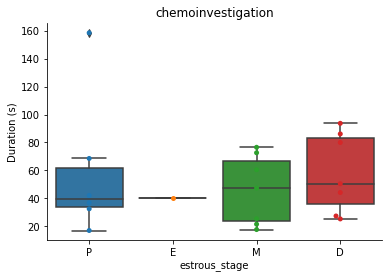

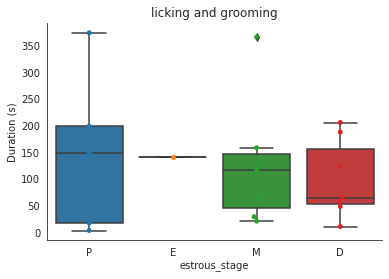

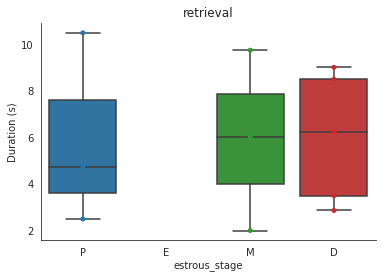

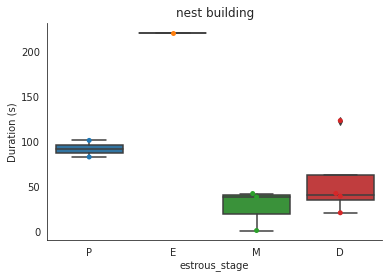

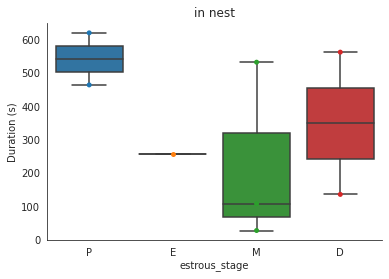

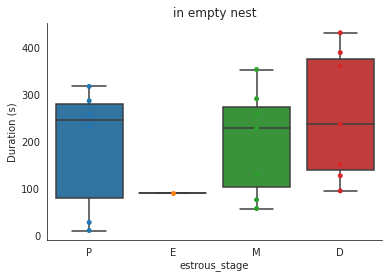

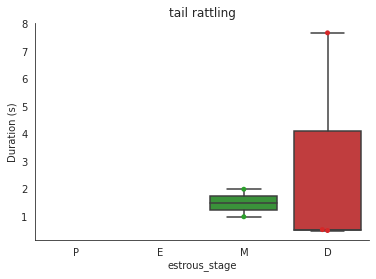

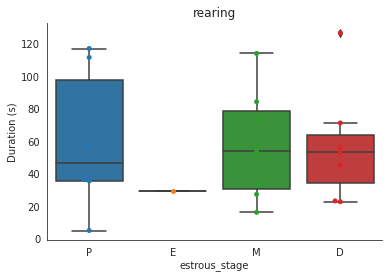

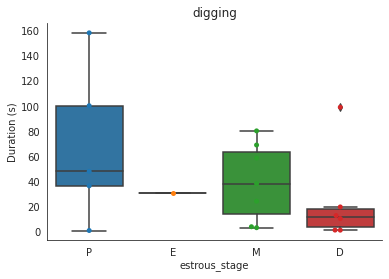

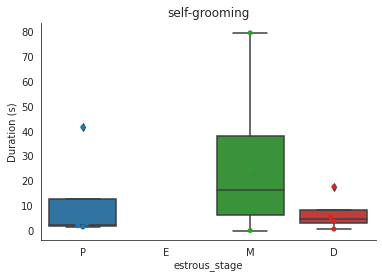

In [10]:
for behavior in behaviors:
    fig,ax = plt.subplots()
    sns.set_style("white")

    sns.boxplot(x = 'estrous_stage',
                y = 'Duration (s)',
                data = df_control_p[df_control_p['Behavior'] == behavior],
                order = ['P', 'E', 'M', 'D'])

    sns.swarmplot(x = 'estrous_stage',
                  y = 'Duration (s)',
                  data = df_control_p[df_control_p['Behavior'] == behavior], 
                  dodge = True, order = ['P', 'E', 'M', 'D'])

    plt.title(behavior)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .7))

    sns.despine()

difference in behaviour frequency and estrous cycle

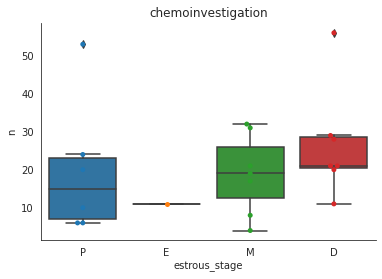

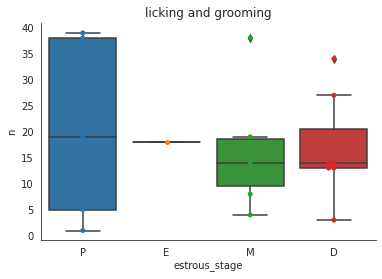

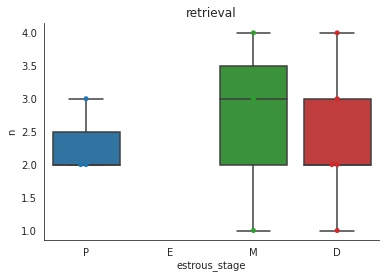

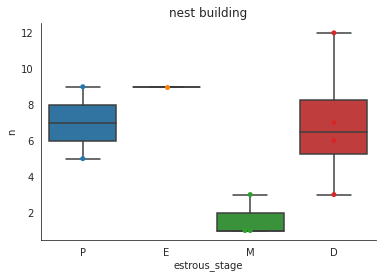

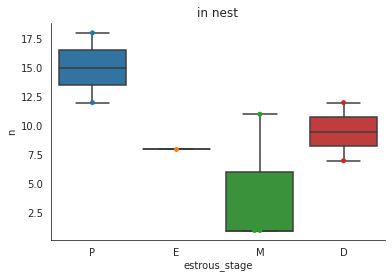

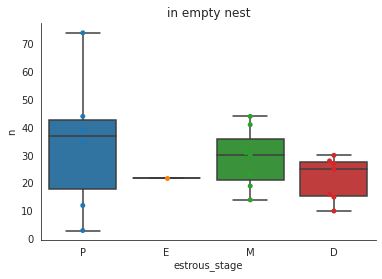

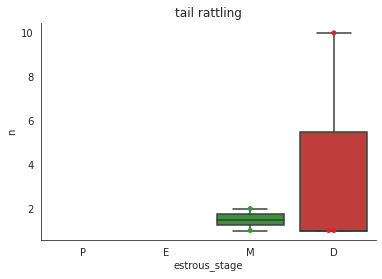

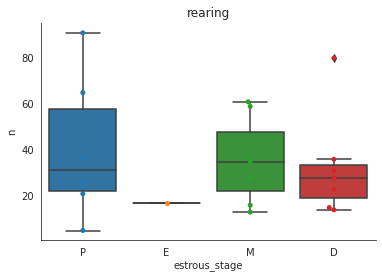

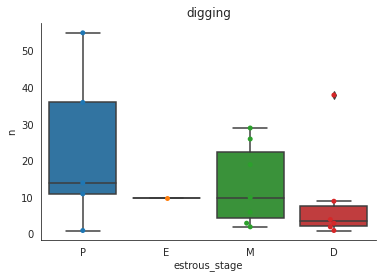

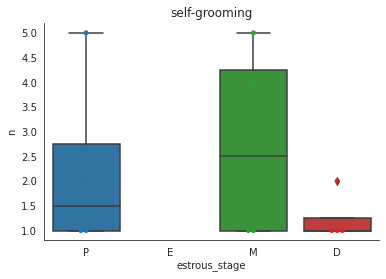

In [11]:
for behavior in behaviors:
    fig,ax = plt.subplots()
    sns.set_style("white")

    sns.boxplot(x = 'estrous_stage',
                y = 'n',
                data = df_control_p[df_control_p['Behavior'] == behavior],
                order = ['P', 'E', 'M', 'D'])

    sns.swarmplot(x = 'estrous_stage',
                  y = 'n',
                  data = df_control_p[df_control_p['Behavior'] == behavior], 
                  dodge = True, order = ['P', 'E', 'M', 'D'])

    plt.title(behavior)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .7))

    sns.despine()

difference in latency and estrous cycle

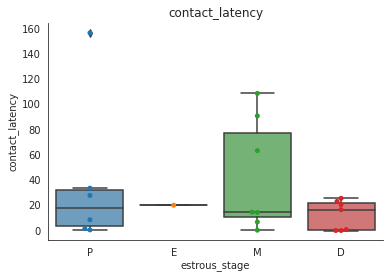

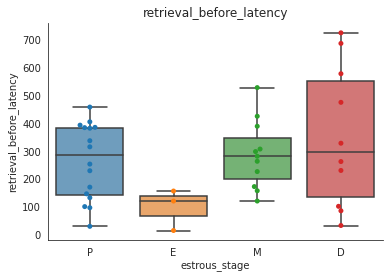

In [10]:
data_first = raw_df[raw_df['exp_time'] == 1]
lat = data_first.merge(df_control.filter(['mice_ID', 'contact_latency'], axis = 1).drop_duplicates(), how = 'outer', on = 'mice_ID')


for latency in ['contact_latency', 'retrieval_before_latency']:
    fig,ax = plt.subplots()
    sns.set_style("white")
    sns.boxplot(x = 'estrous_stage',
                y = latency,
                data = lat,
                order = ['P', 'E', 'M', 'D'])

    sns.swarmplot(x = 'estrous_stage',
                y = latency,
                data = lat,
                order = ['P', 'E', 'M', 'D'])
    
    plt.title(latency)

    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .7))

    sns.despine()

differnce in percentage retrieval and estrous cycle stages

In [11]:
ret_per = lat.groupby('estrous_stage')['retrieval_before_latency'].apply(lambda x: x.notnull().mean()).reset_index(name = 'percentage')

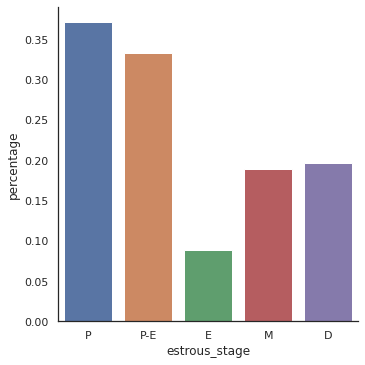

In [12]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set(font="Roboto")
sns.set_style("white")
g = sns.catplot(x = 'estrous_stage', 
                y = 'percentage',
                kind = 'bar', 
                data = ret_per,
                order = ['P', 'P-E', 'E', 'M', 'D'])

# pre phase behaviour paramater and post phase aggression state

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 41.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'chemoinvestigation'),
  Text(1, 0, 'in empty nest'),
  Text(2, 0, 'licking and grooming'),
  Text(3, 0, 'pup introduction'),
  Text(4, 0, 'digging'),
  Text(5, 0, 'rearing'),
  Text(6, 0, 'self-grooming'),
  Text(7, 0, 'trial end'),
  Text(8, 0, 'retrieval'),
  Text(9, 0, 'in nest'),
  Text(10, 0, 'tail rattling'),
  Text(11, 0, 'nest building'),
  Text(12, 0, 'aggressive contact')])

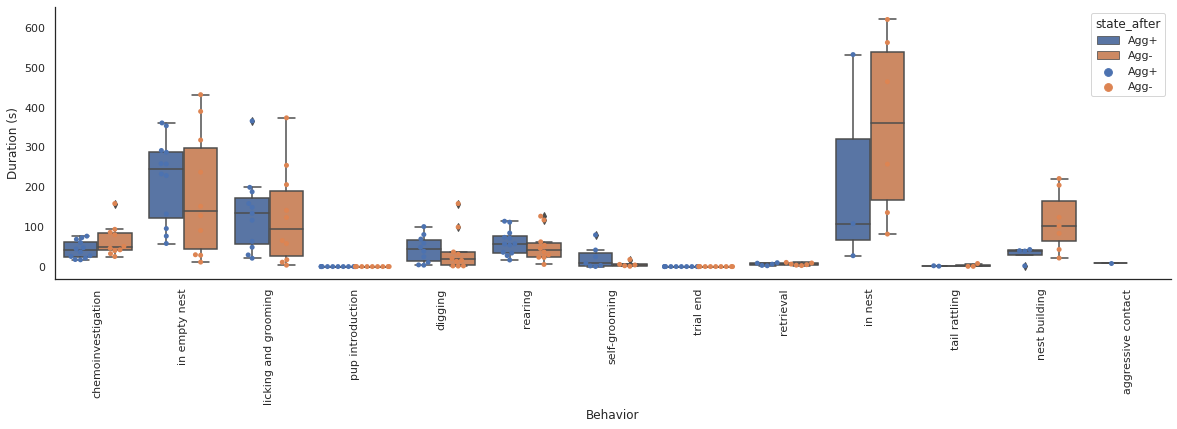

In [11]:
sns.set(rc={'figure.figsize':(20,5)})
sns.set_style("white")

sns.boxplot(x = 'Behavior',
            y = 'Duration (s)',
            hue = 'state_after',
            data = df_control_p)

sns.swarmplot(x = 'Behavior',
            y = 'Duration (s)',
            hue = 'state_after',
            data = df_control_p, dodge = True)

sns.despine()
plt.xticks(rotation='vertical')

comparing contact latency between Agg+ and Agg- in pre and post phase

In [12]:
stat, p = stats.ttest_ind(df_control_p[df_control_p['state_after'] == 'Agg+']['contact_latency'].drop_duplicates(),
                           df_control_p[df_control_p['state_after'] == 'Agg-']['contact_latency'].drop_duplicates(),
                           equal_var = False)

stat, p1 = stats.ttest_ind(df_test_p[df_test_p['state_after'] == 'Agg+']['contact_latency'].drop_duplicates(),
                           df_test_p[df_test_p['state_after'] == 'Agg-']['contact_latency'].drop_duplicates(),
                           equal_var = False)


print(p, p1)

0.06694916575690803 0.010116861997084987


/Users/kohlj/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  if __name__ == '__main__':
/Users/kohlj/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  if __name__ == '__main__':


Text(0.5, -12.5, '')

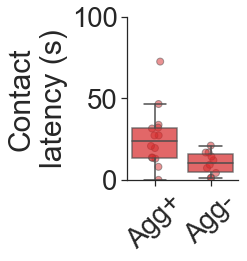

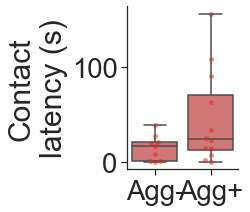

In [81]:
sns.set(rc={"figure.figsize": (2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x = 'state_after', y = 'contact_latency', data = df_test_p.filter(['contact_latency', 'state_after']).drop_duplicates(), 
                 boxprops=dict(alpha=0.7), palette = ['Tab:red'], 
                 showfliers=False, saturation=8)
ax = sns.stripplot(x = 'state_after', y = 'contact_latency', data = df_test_p.filter(['contact_latency', 'state_after']).drop_duplicates(), 
                   palette = ['Tab:red'], marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0)

ax.set(ylabel = 'Contact\nlatency (s)')
ax.set_xticklabels( ('Agg+', 'Agg-'), rotation=45)
ax.set_xlabel('')
plt.ylim(0,100)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/post_phase_contact_latency.pdf',
            bbox_inches='tight', transparent=True, dpi = 300)

nobs = ["n = " + str(i) for i in [9, 13]]
pos = range(len(nobs))
'''
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            [25, 70][tick] + 5,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')
'''  
ax2 = category_plotting_detailed('state_after', 'contact_latency',
                           df_control_p.filter(['contact_latency', 'state_after']).drop_duplicates(), 
                            ['Agg-', 'Agg+'])
ax2.set(ylabel = 'Contact\nlatency (s)')
ax2.set_xlabel('')
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/pre_phase_contact_latency.pdf',
#             bbox_inches='tight', transparent=True, dpi = 300)

In [16]:
_, p_chemo = stats.ttest_ind(df_test_duration[(df_test_duration['state_after'] == 'Agg+') & (df_test_duration['Behavior'] == 'chemoinvestigation')]['Duration (s)'],
                         df_test_duration[(df_test_duration['state_after'] == 'Agg-') & (df_test_duration['Behavior'] == 'chemoinvestigation')]['Duration (s)'],
                        equal_var = False)
_, p_lic = stats.ttest_ind(df_test_duration[(df_test_duration['state_after'] == 'Agg+') & (df_test_duration['Behavior'] == 'licking and grooming')]['Duration (s)'],
                         df_test_duration[(df_test_duration['state_after'] == 'Agg-') & (df_test_duration['Behavior'] == 'licking and grooming')]['Duration (s)'],
                        equal_var = False)
print(p_chemo, p_lic)

ax1 = category_plotting_detailed('state_after', 'Duration (s)',
                                 df_test_duration[df_test_duration['Behavior'].isin(['chemoinvestigation'])])
ax1.set(ylabel = 'chemoinvestigation\nduration (s)')
ax1.set_xlabel('')

category_plotting_detailed('state_after', 'Duration (s)',
                            df_control_duration[df_control_duration['Behavior'] == 'chemoinvestigation'])

nobs = ["n = " + str(i) for i in [10, 13]]
pos = range(len(nobs))
for tick,label in zip(pos,ax1.get_xticklabels()):
    ax1.text(pos[tick],
            [50, 70][tick] + 5,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')
    
ax2 = category_plotting_detailed('state_after', 'Duration (s)', 
                                 df_test_duration[df_test_duration['Behavior'].isin(['licking and grooming'])])
ax2.set(ylabel = 'licking & grooming\nduration (s)')
ax2.set_xlabel('')
category_plotting_detailed('state_after', 'Duration (s)', 
                            df_control_duration[df_control_duration['Behavior'].isin(['licking and grooming'])])
nobs = ["n = " + str(i) for i in [9, 13]]
pos = range(len(nobs))
for tick,label in zip(pos,ax2.get_xticklabels()):
    ax2.text(pos[tick],
            [360, 170][tick] + 5,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')

KeyError: 'state_after'

In [ ]:
sns.set(rc={'figure.figsize':(20,10)})
sns.set(font="Roboto")
sns.set_style("white")

sns.boxplot(x = 'Behavior',
            y = 'Duration (s)',
            hue = 'state_after',
            data = df_control)

sns.swarmplot(x = 'Behavior',
              y = 'Duration (s)',
              hue = 'state_after',
              data = df_control,
              dodge = True, color = 'black')

sns.despine()
plt.xticks(rotation=45)